## EDA (Exploratory data analysis)
### 1. Dataset overview 
Goal: understand the size of the dataset and preview the data

The dataset contains 1025 rows and 14 columns.
A preview if the data shows clinical and demographic variables that will be used to predict heart disease outcomes.

In [11]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [16]:
from src.data.load_data import load_data

#Load data
df = load_data("../data/heart.csv")

In [18]:
df.shape

(1025, 14)

In [19]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [20]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
941,52,0,2,136,196,0,0,169,0,0.1,1,0,2,1
418,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1
988,60,1,0,140,293,0,0,170,0,1.2,1,2,3,0
25,61,0,0,145,307,0,0,146,1,1.0,1,0,3,0
220,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


### 2. Data types and quality
Goal: check column types, duplicates and general structure

The dataset consists mainly of numerical variables, with some categorical/bonary features.
There were 723 duplicated rows identified and removed to improve data quality, so the dataset actually contains 302 rows.

In [21]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [23]:
df.duplicated().sum()

np.int64(723)

In [24]:
df = df.drop_duplicates()

In [25]:
df.shape

(302, 14)

### 3. Missing and invalid values
Goal: check null values and medically implausible zeros.

No missing values were detected using "isnull()".
Additionally, an inspection of key physionlogical variables ("trestbps", "chol", "thalach") showed that there are no zero values that would indicate invalid or missing data.

In [26]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [27]:
invalid_zero_columns = ["trestbps", "chol", "thalach"]
df[invalid_zero_columns].eq(0).sum()

trestbps    0
chol        0
thalach     0
dtype: int64

### 4. Target distribution
Goal: understand class balance.

The target variable is relatively balanced, with approximately 45.7% if patients without a disease and 54.3% with heart disease.
This balanced distribution reduces the risk of bias toward a single class and allows the use of standard evaluation metrics without requiring special handling for class imbalance.

In [28]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [29]:
df["target"].value_counts(normalize=True)

target
1    0.543046
0    0.456954
Name: proportion, dtype: float64

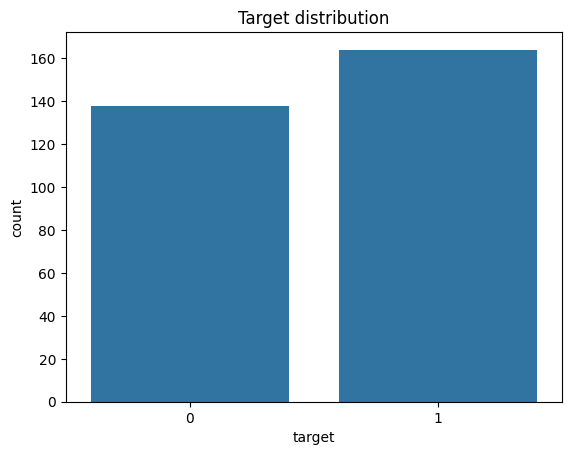

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Target distribution")
plt.show()

### 5. Feature distribution
Goal: understand how individual feature behave.

The distribution of continuous features reveal a mix of approximately normal distribution and skewed patterns.
Features such as age and thalach appear relatively symmetric and well-distributed, suggesting stable variability across the dataset. In contrast, features like oldpeak and chol exibit left-skewed distributions, with a concentration of lower values and a long tail of higher observations.

The distribution of categorical features reveal a mix of binary imbalance and multi-class imbalance.
Features such as sex and exang show moderate imbalance, with a higher proportion of one category compared to the other, Similarly, fb is heavily skewed toward the non-elevated category, indicating that most patients do not exhibit greater than 120 mg/dl.

Multi-class features like cp, slope, ca, and thal display uneven distributions across categories. In particular, some cateogries (e.g. higher values of ca or less frequent thal categories) are relatively underrepresented.

This imbalance my influence the model learning by biasing predictions towards more frequent categories. 

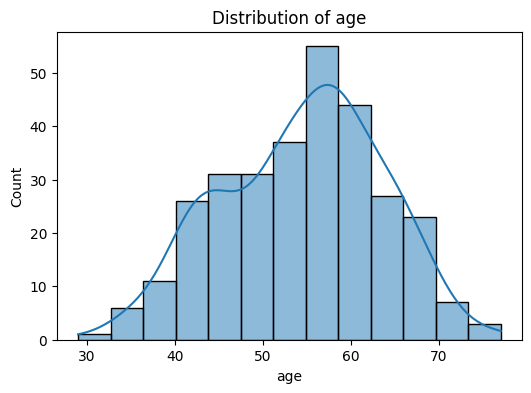

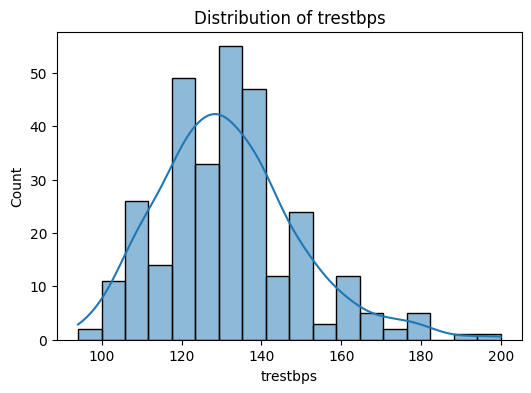

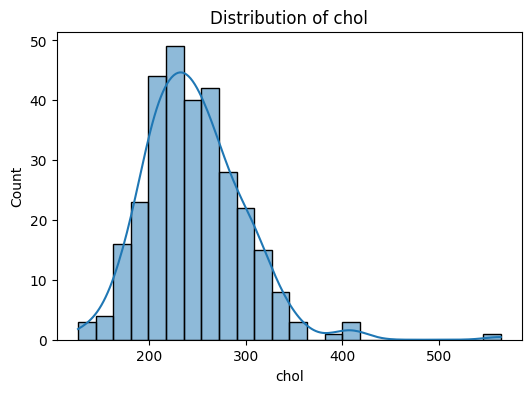

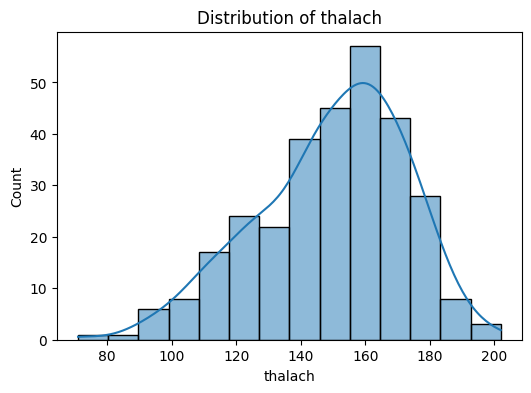

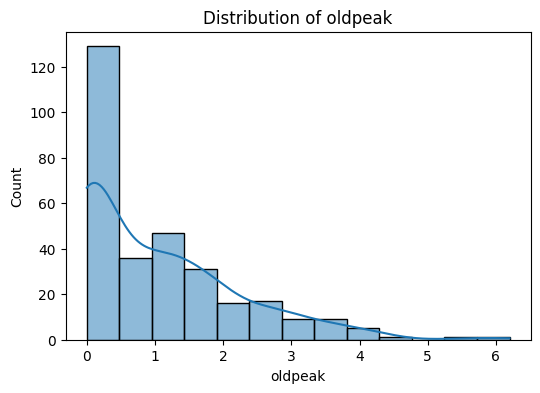

In [ ]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

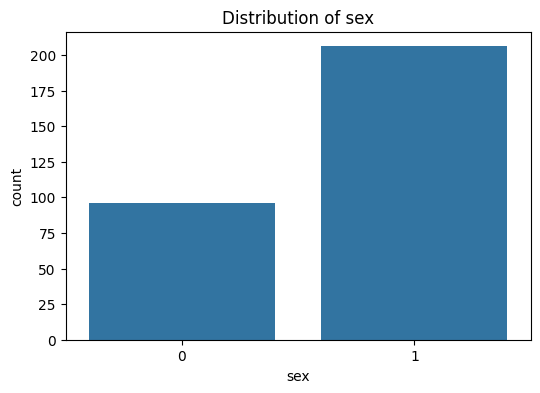

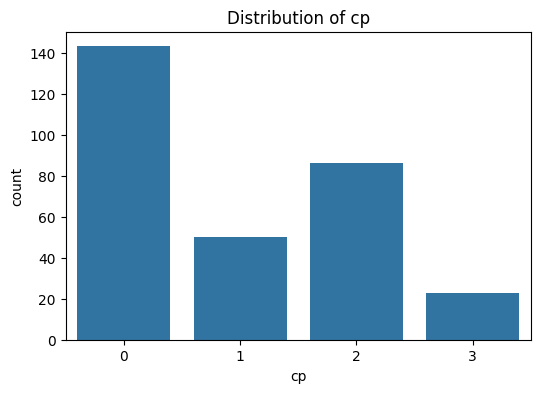

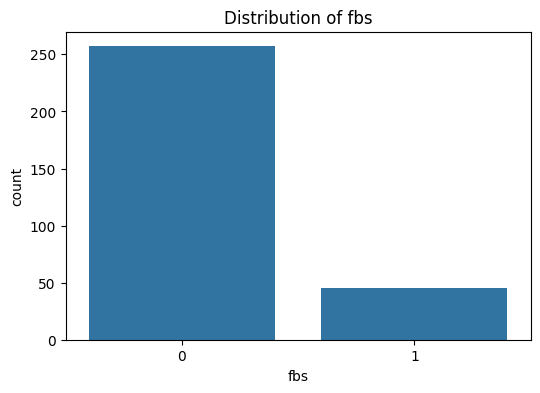

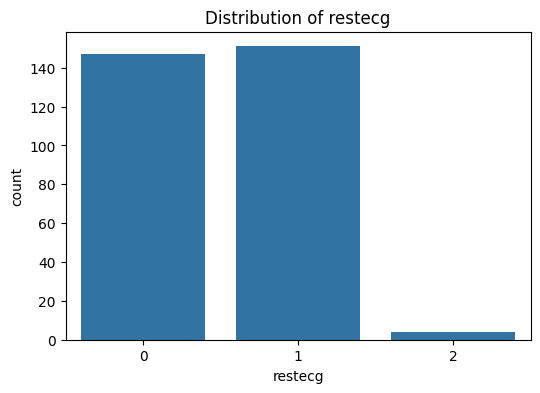

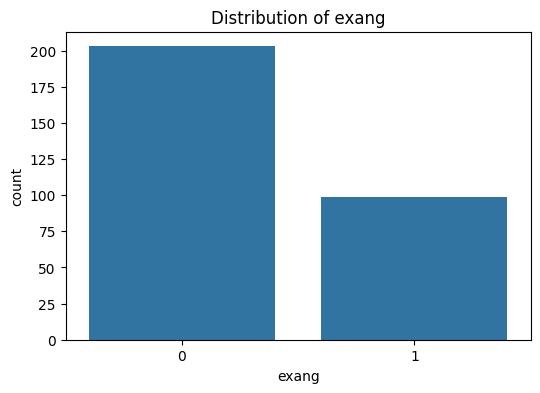

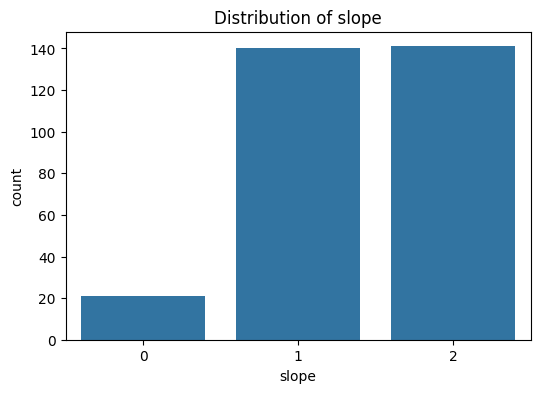

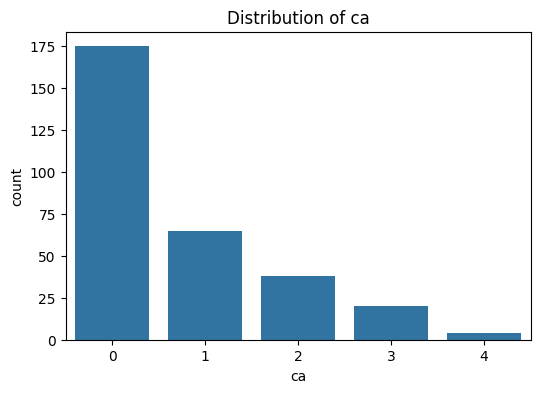

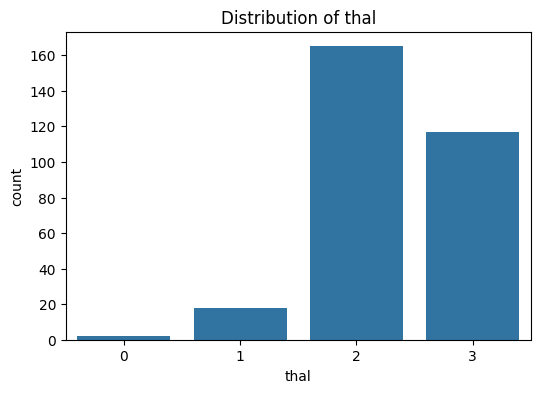

In [34]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=feature, data=df)
    plt.title(f"Distribution of {feature}")
    plt.show()

### 6. Feature vs target analysis
Goal: see how each features relates to the target.

